
# Score-Based Generative Models (RLD course)

This exercise notebook introduces score-based generative models from a Langevin
dynamics perspective, contrasting with the stochastic/denoising interpretation
of diffusion models.

The lab is structured in three parts:
- **Part 1**: Score-based fundamentals with 2D examples (Main session)
- **Part 2**: Score-based models for images and connection to diffusion (Main session)
- **Part 3**: Advanced sampling methods - SDE/ODE formulation (Optional, home learning)

A good overview can be found in [Yang Song's blog](https://yang-song.net/blog/2021/score/)
and the paper "Score-Based Generative Modeling through Stochastic Differential Equations".

## Required Packages

Before starting, please ensure you have the following packages installed:

**Core packages:**
- `torch` (>=1.12) - PyTorch for deep learning
- `torchvision` - Vision utilities and datasets
- `matplotlib` - Plotting and visualization
- `numpy` - Numerical computing
- `tqdm` - Progress bars

**Optional (for Part 3):**
- `scipy` - For ODE solving in Part 3 (optional advanced section)

**Installation commands:**
- **Conda:** `conda install pytorch torchvision matplotlib numpy tqdm scipy -c pytorch`
- **Pip:** `pip install torch torchvision matplotlib numpy tqdm scipy`

In [1]:
# For Google Colab users: Run this cell to install required packages
!pip install torch torchvision matplotlib numpy tqdm scipy


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

# Import the necessary modules
from functools import partial
import math
import os

# Fix OpenMP library conflict on macOS (common issue with PyTorch)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# Use regular tqdm instead of autonotebook to avoid potential issues
try:
    from tqdm import tqdm
except ImportError:
    # Fallback if tqdm is not installed
    tqdm = lambda x, **kwargs: x

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.utils import make_grid

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# For Part 3 (optional)
try:
    from scipy.integrate import odeint  # type: ignore
except ImportError:
    odeint = None  # type: ignore

# Device selection: prefer MPS (Apple Silicon) > CUDA > CPU
# Note: MPS can be unstable in some environments, use CPU if issues occur
try:
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
except Exception as e:
    # Fallback to CPU if device selection fails
    print(f"Warning: Device selection failed ({e}), using CPU")
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [3]:

# Main experimental settings
num_noise_levels = 10  # Number of noise levels for annealed Langevin
epochs = 5  # Training epochs for Part 2

In [4]:

if os.environ.get("TESTING_MODE", "off") == "ON":
    num_noise_levels = 3
    epochs = 1
    plt.show = lambda *args, **kwargs: None


# Part 1: Score-Based Fundamentals

In this part, we'll build intuition about score-based generative models using
simple 2D examples before moving to images.


## 1.1 Understanding the Score Function

The **score function** is the gradient of the log-probability density:
$$s_\theta(x) = \nabla_x \log p_\theta(x)$$

Why learn gradients instead of probabilities?
- We don't need the normalization constant (it disappears in the gradient)
- Gradients point toward higher probability regions
- We can sample by following gradients (Langevin dynamics)

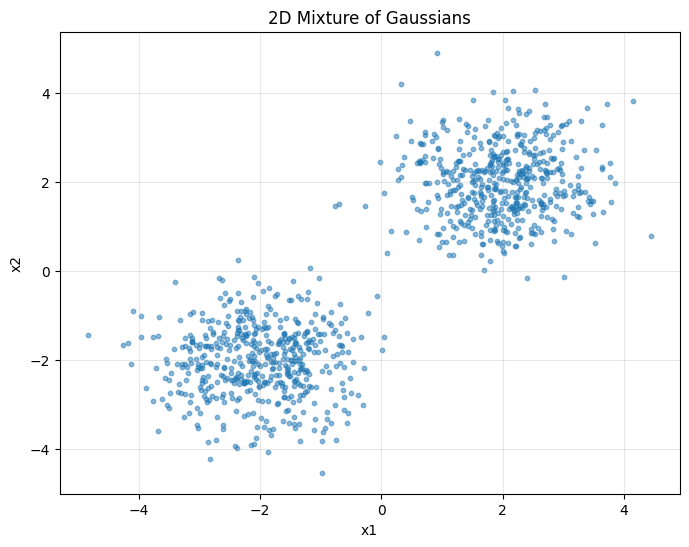

In [5]:

# Let's visualize score functions on a simple 2D distribution
# We'll use a mixture of Gaussians as our example

def create_2d_mixture(num_samples=1000, device='cpu'):
    """Create a 2D mixture of Gaussians dataset"""
    # Two Gaussian components
    mu1 = torch.tensor([2.0, 2.0])
    mu2 = torch.tensor([-2.0, -2.0])
    sigma = 0.8

    # Sample from both components
    n1 = num_samples // 2
    n2 = num_samples - n1

    samples1 = torch.randn(n1, 2) * sigma + mu1
    samples2 = torch.randn(n2, 2) * sigma + mu2

    data = torch.cat([samples1, samples2], dim=0)
    return data.to(device)

# Create and visualize the data
data_2d = create_2d_mixture(1000, device)
plt.figure(figsize=(8, 6))
plt.scatter(data_2d[:, 0].cpu().numpy(), data_2d[:, 1].cpu().numpy(), alpha=0.5, s=10)
plt.title("2D Mixture of Gaussians")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.show()


## 1.2 Score Matching

To learn the score function, we use **denoising score matching**. The idea is:
1. Add noise to data: $\tilde{x} = x + \sigma \epsilon$ where $\epsilon \sim \mathcal{N}(0, I)$
2. Learn to predict the score of the noisy distribution: $s_\theta(\tilde{x}, \sigma) \approx \nabla_{\tilde{x}} \log p_\sigma(\tilde{x})$
3. The score matching objective is:
   $$\mathcal{L} = \mathbb{E}_{x \sim p_{data}, \epsilon \sim \mathcal{N}(0,I), \sigma} \left[ \| s_\theta(\tilde{x}, \sigma) + \frac{\epsilon}{\sigma} \|^2 \right]$$

Note: The true score of a Gaussian noise distribution is $-\frac{\epsilon}{\sigma}$,
so we're learning to predict this.

In [6]:

class ScoreNetwork2D(nn.Module):
    """Simple MLP for 2D score estimation"""

    def __init__(self, hidden_dim=128, num_layers=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(3, hidden_dim))  # 2D input + 1D noise level
        layers.append(nn.SiLU())

        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())

        layers.append(nn.Linear(hidden_dim, 2))  # 2D output (score)
        self.net = nn.Sequential(*layers)

    def forward(self, x, sigma):
        """
        Args:
            x: (batch_size, 2) - 2D points
            sigma: (batch_size,) - noise levels
        Returns:
            score: (batch_size, 2) - score function
        """
        # Concatenate x and sigma
        sigma_expanded = sigma.unsqueeze(-1)  # (batch_size, 1)
        x_with_sigma = torch.cat([x, sigma_expanded], dim=-1)  # (batch_size, 3)
        return self.net(x_with_sigma)


Now let's implement the denoising score matching loss:

In [7]:
def score_matching_loss(model, data, sigma, device='cpu'):
    """
    Denoising score matching loss

    Args:
        model: Score network
        data: (batch_size, 2) - clean data points
        sigma: (batch_size,) - noise levels
        device: Device to use
    Returns:
        loss: Scalar loss value
    """
    batch_size = data.shape[0]

    # Generate random noise
    epsilon = torch.randn_like(data).to(device)

    # Add noise to data
    noisy_data = data + sigma.unsqueeze(-1) * epsilon

    # Get predicted score from the model
    s_theta = model(noisy_data, sigma)

    # Calculate the true score of the noisy data (which is -epsilon / sigma)
    target_score = -epsilon / sigma.unsqueeze(-1)

    # Calculate the loss (mean squared error between predicted and target score)
    loss = torch.mean(torch.sum((s_theta - target_score)**2, dim=-1))

    return loss

# Test the loss function
model_2d = ScoreNetwork2D().to(device)
test_data = torch.randn(32, 2).to(device)
test_sigma = torch.ones(32).to(device) * 0.5
loss = score_matching_loss(model_2d, test_data, test_sigma, device)
print(f"Test loss: {loss.item():.4f}")

Test loss: 9.5811



## 1.3 Training the Score Network

Let's train the score network on our 2D mixture of Gaussians:

In [8]:
batch_size = 128
learning_rate = 1e-3
num_epochs = 5000

# Prepare data loader
data_loader = DataLoader(
    data_2d, batch_size=batch_size, shuffle=True
)

model_2d = ScoreNetwork2D().to(device)
optimizer = torch.optim.Adam(model_2d.parameters(), lr=learning_rate)
sigma_levels = torch.linspace(1.0, 0.01, num_noise_levels).to(device) # From high noise to low noise
model_2d.train()
for epoch in tqdm(range(num_epochs), desc="Training 2D Score Network"):
    for batch_data in data_loader:
        optimizer.zero_grad()
        idx = torch.randint(0, num_noise_levels, (batch_data.shape[0],), device=device)
        batch_sigma = sigma_levels[idx]

        loss = score_matching_loss(model_2d, batch_data, batch_sigma, device)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.6f}")

print("Training completed!")

Training 2D Score Network:  10%|█         | 506/5000 [00:09<01:27, 51.24it/s]

Epoch 500/5000, Loss: 895.182251


Training 2D Score Network:  20%|██        | 1010/5000 [00:19<01:14, 53.72it/s]

Epoch 1000/5000, Loss: 2180.406982


Training 2D Score Network:  30%|███       | 1508/5000 [00:28<01:04, 53.93it/s]

...

Epoch 4000/5000, Loss: 2461.691650


Training 2D Score Network:  90%|█████████ | 4508/5000 [01:24<00:09, 53.70it/s]

Epoch 4500/5000, Loss: 2000.531738


Training 2D Score Network: 100%|██████████| 5000/5000 [01:33<00:00, 53.45it/s]

Epoch 5000/5000, Loss: 935.262817
Training completed!



## 1.4 Langevin Dynamics Sampling

Once we have a trained score network, we can sample using **Langevin dynamics**:
$$x_{t+1} = x_t + \frac{\epsilon}{2} \nabla_x \log p(x_t) + \sqrt{\epsilon} z$$

where $z \sim \mathcal{N}(0, I)$ and $\epsilon$ is the step size.

For better sampling, we use **annealed Langevin dynamics**:
- Start with high noise level (large $\sigma$)
- Gradually decrease noise level
- At each level, run multiple Langevin steps

In [9]:

def langevin_step(model, x, sigma, step_size, device='cpu'):
    """
    Single Langevin dynamics step

    Args:
        model: Score network
        x: (batch_size, 2) - current samples
        sigma: (batch_size,) - current noise levels
        step_size: Step size for Langevin dynamics
        device: Device to use
    Returns:
        x_new: (batch_size, 2) - updated samples
    """
    # Get score
    score = model(x, sigma)

    # Langevin step: x_new = x + (step_size/2) * score + sqrt(step_size) * noise
    noise = torch.randn_like(x)
    x_new = x + (step_size / 2) * score + math.sqrt(step_size) * noise

    return x_new

Annealed Langevin Sampling: 100%|██████████| 10/10 [00:00<00:00, 215.46it/s]


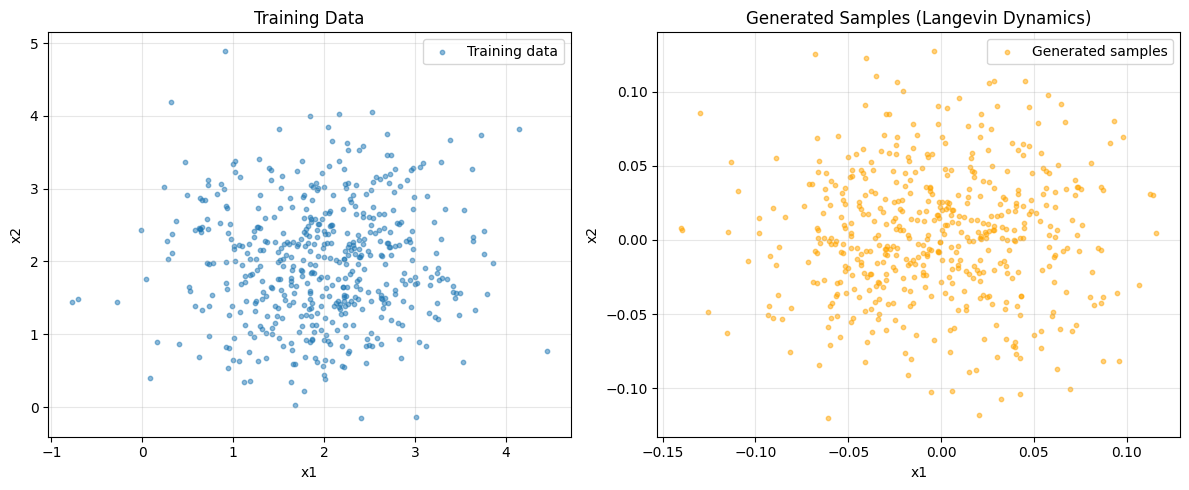

In [10]:

def annealed_langevin_sample(model, num_samples, sigma_levels, steps_per_level, step_size, device='cpu'):
    """
    Annealed Langevin dynamics sampling

    Args:
        model: Trained score network
        num_samples: Number of samples to generate
        sigma_levels: List of noise levels (from high to low)
        steps_per_level: Number of Langevin steps per noise level
        step_size: Step size for Langevin dynamics
        device: Device to use
    Returns:
        samples: (num_samples, 2) - generated samples
    """
    # Initialize samples from random noise (e.g., from the highest noise level's distribution)
    x = torch.randn(num_samples, 2).to(device) * sigma_levels[0]

    # Iterate through noise levels from high to low
    for i, sigma in enumerate(tqdm(sigma_levels, desc="Annealed Langevin Sampling")):
        current_sigma = torch.ones(num_samples).to(device) * sigma
        for _ in range(steps_per_level):
            x = langevin_step(model, x, current_sigma, step_size, device)

    return x

# Test sampling
with torch.no_grad():
    model_2d.eval()
    samples = annealed_langevin_sample(
        model_2d,
        num_samples=500,
        sigma_levels=sigma_levels.flip(0),  # From high to low
        steps_per_level=10,
        step_size=2e-5,
        device=device
    )

# Visualize generated samples
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(data_2d[:500, 0].cpu().numpy(), data_2d[:500, 1].cpu().numpy(),
            alpha=0.5, s=10, label='Training data')
plt.title("Training Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(samples[:, 0].cpu().numpy(), samples[:, 1].cpu().numpy(),
            alpha=0.5, s=10, label='Generated samples', color='orange')
plt.title("Generated Samples (Langevin Dynamics)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 1.5 Visualizing Score Fields

Let's visualize the learned score function to understand what it's doing:

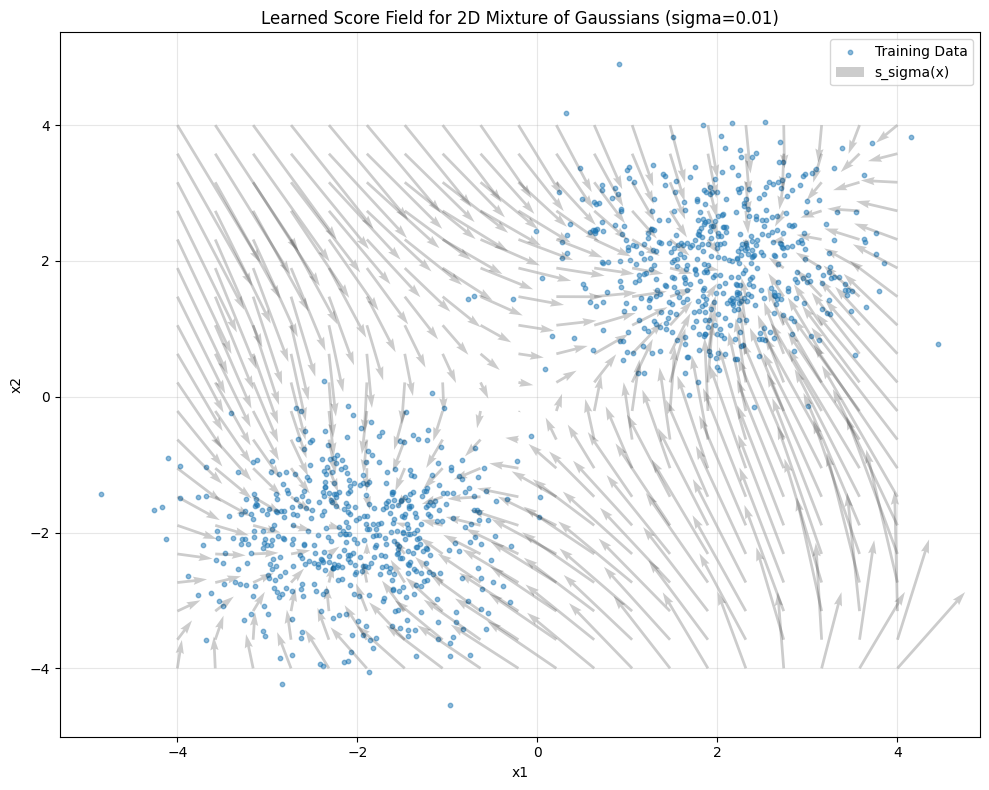

In [11]:
model_2d.eval()
with torch.no_grad():
    x_range = np.linspace(-4, 4, 20)
    y_range = np.linspace(-4, 4, 20)
    X, Y = np.meshgrid(x_range, y_range)
    grid_points = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=-1), dtype=torch.float32).to(device)

    visual_sigma = sigma_levels[-1]
    sigmas_for_grid = torch.full((grid_points.shape[0],), visual_sigma.item(), device=device)
    predicted_scores = model_2d(grid_points, sigmas_for_grid)
    predicted_scores_np = predicted_scores.cpu().numpy()
    U = predicted_scores_np[:, 0].reshape(X.shape)
    V = predicted_scores_np[:, 1].reshape(Y.shape)
    plt.figure(figsize=(10, 8))
    plt.scatter(data_2d[:, 0].cpu().numpy(), data_2d[:, 1].cpu().numpy(),
                alpha=0.5, s=10, label='Training Data')

    plt.quiver(X, Y, U, V, color='black', alpha=0.2, scale=50, label='s_sigma(x)')

    plt.title(f"Learned Score Field for 2D Mixture of Gaussians (sigma={visual_sigma.item():.2f})")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



# Part 2: Score-Based Models for Images and Connection to Diffusion

Now we'll apply score-based models to image generation (MNIST) and understand
the connection to diffusion models.


## 2.1 Loading MNIST Dataset

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Image shape: torch.Size([28, 28])
Channels: 1


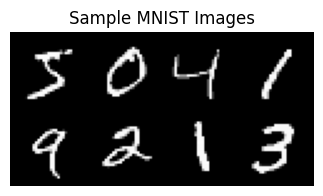

In [12]:

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0, 1] range and adds channel dimension
    transforms.Lambda(lambda x: (x - 0.5) * 2.0)  # [-1,1]
])

train_data = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Get image properties
sample_image = train_data[0][0]
image_channels = sample_image.shape[0]  # Should be 1 for grayscale MNIST
image_shape = sample_image.shape[1:]  # (28, 28)

print(f"Image shape: {image_shape}")
print(f"Channels: {image_channels}")

# Show some images
sample_images = torch.stack([train_data[i][0] for i in range(8)])
grid = make_grid(sample_images, nrow=4)
plt.figure(figsize=(8, 2))
plt.imshow(grid.permute(1, 2, 0).squeeze().cpu().numpy(), cmap='gray')
plt.axis('off')
plt.title("Sample MNIST Images")
plt.show()


## 2.2 U-Net Architecture for Score Estimation

For images, we need a more sophisticated architecture. We'll use a U-Net,
similar to what's used in diffusion models, but adapted for score estimation.

In [13]:

class SinusoidalPositionEmbeddings(nn.Module):
    """Positional embeddings for time/noise level"""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        assert dim % 2 == 0, "Positional embeddings should be multiples of 2"

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [14]:

class Block(nn.Module):
    def __init__(self, dim, dim_out, groups=8):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim_out, 3, padding=1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift=None):
        x = self.proj(x)
        x = self.norm(x)
        if scale_shift is not None:
            scale, shift = scale_shift
            x = x * (scale + 1) + shift
        x = self.act(x)
        return x

class ResnetBlock(nn.Module):
    def __init__(self, dim, dim_out, *, time_emb_dim=None, groups=8):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, dim_out))
            if time_emb_dim
            else None
        )
        self.block1 = Block(dim, dim_out, groups=groups)
        self.block2 = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb=None):
        h = self.block1(x)
        if self.mlp is not None and time_emb is not None:
            time_emb = self.mlp(time_emb)
            h = h + time_emb.unsqueeze(-1).unsqueeze(-1)
        h = self.block2(h)
        return h + self.res_conv(x)

def Upsample(dim):
    return nn.ConvTranspose2d(dim, dim, kernel_size=4, stride=2, padding=1)

def Downsample(dim):
    return nn.Conv2d(dim, dim, kernel_size=4, stride=2, padding=1)

class Unet(nn.Module):
    def __init__(
        self,
        dim,
        *,
        init_dim=None,
        out_dim=None,
        dim_mults=(1, 2, 4),
        channels=1,
        time_dim=None,
        resnet_block_groups=4,
    ):
        super().__init__()
        self.channels = channels
        self.time_dim = time_dim

        init_dim = init_dim or (dim // 3 * 2)
        # Ensure init_dim is divisible by resnet_block_groups
        init_dim = ((init_dim + resnet_block_groups - 1) // resnet_block_groups) * resnet_block_groups
        self.init_conv = nn.Conv2d(channels, init_dim, 7, padding=3)

        dims = [init_dim, *(dim * m for m in dim_mults)]
        # Ensure all dims are divisible by resnet_block_groups
        dims = [((d + resnet_block_groups - 1) // resnet_block_groups) * resnet_block_groups for d in dims]
        in_out = list(zip(dims[:-1], dims[1:]))

        resnet_block = partial(ResnetBlock, groups=resnet_block_groups)

        self.downs = nn.ModuleList([])
        self.ups = nn.ModuleList([])
        num_resolutions = len(in_out)

        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (num_resolutions - 1)
            self.downs.append(
                nn.ModuleList(
                    [
                        resnet_block(dim_in, dim_out, time_emb_dim=time_dim),
                        resnet_block(dim_out, dim_out, time_emb_dim=time_dim),
                        Downsample(dim_out) if not is_last else nn.Identity(),
                    ]
                )
            )

        mid_dim = dims[-1]
        self.mid_block1 = ResnetBlock(mid_dim, mid_dim, time_emb_dim=time_dim, groups=resnet_block_groups)
        self.mid_block2 = ResnetBlock(mid_dim, mid_dim, time_emb_dim=time_dim, groups=resnet_block_groups)

        # Store the actual channel dimensions for skip connections
        # In downsample: we save feature maps with dim_out channels
        # In upsample: we concatenate x (from previous upsample with dim_out channels) with h (saved dim_out channels)
        # So the actual concat_dim should be dim_out + dim_out, not dim_out + dim_in
        for ind, (dim_in, dim_out) in enumerate(reversed(in_out)):
            is_last = ind >= (num_resolutions - 1)
            # The skip connection h has dim_out channels (from downsample)
            # x coming from previous upsample also has dim_out channels
            # So we concatenate dim_out + dim_out
            concat_dim = dim_out + dim_out
            # Ensure concat_dim is divisible by resnet_block_groups
            concat_dim = ((concat_dim + resnet_block_groups - 1) // resnet_block_groups) * resnet_block_groups
            self.ups.append(
                nn.ModuleList(
                    [
                        resnet_block(concat_dim, dim_in, time_emb_dim=time_dim),
                        resnet_block(dim_in, dim_in, time_emb_dim=time_dim),
                        Upsample(dim_in) if not is_last else nn.Identity(),
                    ]
                )
            )

        out_dim = out_dim or channels
        # Final conv receives concatenated x (dims[0] channels) + r (init_dim channels)
        # Since init_dim == dims[0] after rounding, we get 2 * dims[0] channels
        final_conv_input_dim = dims[0] + init_dim  # This equals 2 * dims[0] since init_dim == dims[0]
        # Ensure it's divisible by resnet_block_groups
        final_conv_input_dim = ((final_conv_input_dim + resnet_block_groups - 1) // resnet_block_groups) * resnet_block_groups
        self.final_conv = nn.Sequential(
            Block(final_conv_input_dim, dims[0], groups=resnet_block_groups), nn.Conv2d(dims[0], out_dim, 1)
        )

    def forward(self, x, time):
        x = self.init_conv(x)
        r = x.clone()

        h = []
        for idx, (block1, block2, downsample) in enumerate(self.downs):
            x = block1(x, time)
            x = block2(x, time)
            h.append(x)
            x = downsample(x)

        x = self.mid_block1(x, time)
        x = self.mid_block2(x, time)

        for idx, (block1, block2, upsample) in enumerate(self.ups):
            h_popped = h.pop()
            x = torch.cat((x, h_popped), dim=1)
            x = block1(x, time)
            x = block2(x, time)
            x = upsample(x)

        x = torch.cat((x, r), dim=1)
        return self.final_conv(x)

In [15]:

class ScoreNetwork(nn.Module):
    """U-Net based score network for images"""

    def __init__(self, dim, channels=1, time_dim=32):
        super().__init__()
        self.image_size = dim
        self.channels = channels
        self.time_dim = time_dim

        self.time_embed = SinusoidalPositionEmbeddings(time_dim)
        self.unet = Unet(
            dim=64,
            init_dim=None,
            out_dim=channels,
            dim_mults=(1, 2, 4),
            channels=channels,
            time_dim=time_dim,
            resnet_block_groups=8,
        )

    def forward(self, x, sigma):
        time_emb = self.time_embed(sigma)
        score = self.unet(x, time_emb)
        return score

# Initialize model
model = ScoreNetwork(image_shape[0], image_channels, time_dim=32).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 7,391,985



## 2.3 Training the Score Network

We'll train using denoising score matching on noisy images at multiple noise levels.

In [16]:

def score_matching_loss_images(model, images, sigma, device='cpu'):
    """
    Denoising score matching loss for images

    Args:
        model: Score network
        images: (batch_size, C, H, W) - clean images
        sigma: (batch_size,) - noise levels
        device: Device to use
    Returns:
        loss: Scalar loss value
    """
    batch_size = images.size(0)
    sigma = sigma.view(-1, 1, 1, 1)
    noise = torch.randn_like(images)
    x_tilde = images + sigma * noise
    score = model(x_tilde, sigma.squeeze())
    loss = torch.mean(
        torch.sum(
            sigma**2 * (score + noise / sigma) ** 2,
            dim=[1, 2, 3]
        )
    )

    return loss



Now let's train the model:

In [17]:
batch_size_images = 128
learning_rate_images = 1e-4
num_epochs_images = 10 # Use the global 'epochs' variable

train_loader = DataLoader(
    train_data, batch_size=batch_size_images, shuffle=True, num_workers=0
)

optimizer_images = torch.optim.Adam(model.parameters(), lr=learning_rate_images)

model.train()
print(f"Starting training for image score network with {num_epochs_images} epochs...")
for epoch in tqdm(range(num_epochs_images), desc="Training Image Score Network"):
    for batch_idx, (batch_images, _) in enumerate(train_loader):
        batch_images = batch_images.to(device)

        optimizer_images.zero_grad()

        # Randomly select a noise level for each image in the batch
        idx = torch.randint(0, num_noise_levels, (batch_images.shape[0],), device=device)
        batch_sigma = sigma_levels[idx]

        loss = score_matching_loss_images(model, batch_images, batch_sigma, device)
        loss.backward()
        optimizer_images.step()

    if (epoch + 1) % 1 == 0 or epoch == num_epochs_images - 1:
        print(f"Epoch {epoch + 1}/{num_epochs_images}, Loss: {loss.item():.6f}")

print("Training completed!")

Starting training for image score network with 10 epochs...


Training Image Score Network:  10%|█         | 1/10 [00:39<05:58, 39.82s/it]

Epoch 1/10, Loss: 157.215988


Training Image Score Network:  20%|██        | 2/10 [01:19<05:16, 39.62s/it]

Epoch 2/10, Loss: 140.224792


...

Epoch 8/10, Loss: 139.244003


Training Image Score Network:  90%|█████████ | 9/10 [05:55<00:39, 39.53s/it]

Epoch 9/10, Loss: 109.283104


Training Image Score Network: 100%|██████████| 10/10 [06:35<00:00, 39.56s/it]

Epoch 10/10, Loss: 110.617615
Training completed!



## 2.4 Mathematical Connection to Diffusion Models

A key insight is that **score-based models and diffusion models are mathematically equivalent**!

In diffusion models, we learn to predict noise: $\epsilon_\theta(x_t, t)$

In score-based models, we learn the score: $s_\theta(x, \sigma) = \nabla_x \log p_\sigma(x)$

The connection is:
$$\epsilon_\theta(x_t, t) = -\sigma_t \cdot s_\theta(x_t, \sigma_t)$$

This means: **predicting noise is equivalent to learning the score function** (up to a scaling factor)!

In [18]:

# Let's verify this connection by showing the relationship
# If we have a noisy image x_tilde = x + sigma * epsilon,
# then the score is: score = -epsilon / sigma
# And if we predict noise: noise_pred = epsilon
# Then: noise_pred = -sigma * score

print("Mathematical Connection:")
print("=" * 50)
print("In diffusion models: predict noise ε_θ(x_t, t)")
print("In score-based models: learn score s_θ(x, σ) = ∇_x log p_σ(x)")
print()
print("Connection: ε_θ(x_t, t) = -σ_t · s_θ(x_t, σ_t)")
print()
print("This means both approaches learn the same underlying information!")
print("=" * 50)

Mathematical Connection:
In diffusion models: predict noise ε_θ(x_t, t)
In score-based models: learn score s_θ(x, σ) = ∇_x log p_σ(x)

Connection: ε_θ(x_t, t) = -σ_t · s_θ(x_t, σ_t)

This means both approaches learn the same underlying information!



## 2.5 Image Generation with Annealed Langevin Dynamics

Now let's generate images using the trained score network:

In [19]:

def langevin_step_images(model, x, sigma, step_size, device='cpu'):
    """
    Single Langevin dynamics step for images

    Args:
        model: Score network
        x: (batch_size, C, H, W) - current images
        sigma: (batch_size,) - current noise levels
        step_size: Step size for Langevin dynamics
        device: Device to use
    Returns:
        x_new: (batch_size, C, H, W) - updated images
    """
    # Get score
    score = model(x, sigma)

    # Langevin step
    noise = torch.randn_like(x)
    x_new = x + (step_size / 2) * score + math.sqrt(step_size) * noise

    return x_new

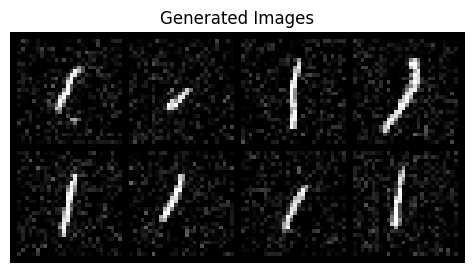

In [29]:
def annealed_langevin_sample_images(
    model,
    num_samples,
    sigma_levels,
    steps_per_level,
    step_size,
    image_shape,
    channels,
    device="cpu"
):
    """
    Annealed Langevin Dynamics sampling (correct version)

    Returns:
        samples in [-1, 1]
    """

    # Initialisation depuis N(0, I)
    x = torch.randn(
        num_samples,
        channels,
        image_shape[0],
        image_shape[1],
        device=device
    )

    model.eval()

    for sigma in sigma_levels:  # déjà du plus grand au plus petit
        alpha = step_size * (sigma / sigma_levels[-1]) ** 2

        sigma_tensor = torch.full(
            (num_samples,),
            sigma,
            device=device
        )

        for _ in range(steps_per_level):
            x.requires_grad_(True)

            score = model(x, sigma_tensor)

            noise = torch.randn_like(x)

            x = x + alpha * score + torch.sqrt(2 * alpha) * noise
            x = x.detach()

    return x

sigs = [10 ,6 ,4,3,2,1.00, 0.5, 0.20]
sigs = [x*1 for x in sigs]
sigma_levels = torch.tensor(sigs,
    device=device
)

generated_samples = annealed_langevin_sample_images(
    model=model,
    num_samples=8,
    sigma_levels=sigma_levels,      # déjà high -> low
    steps_per_level=200,
    step_size=0.01,
    image_shape=image_shape,
    channels=image_channels,
    device=device
)

def denormalize(x):
    return (x.clamp(-1, 1) + 1) / 2

from torchvision.utils import make_grid

grid = make_grid(denormalize(generated_samples), nrow=4)

plt.figure(figsize=(10, 3))
plt.imshow(grid.permute(1, 2, 0).squeeze().cpu(), cmap="gray")
plt.axis("off")
plt.title("Generated Images")
plt.show()


In [21]:
x, _ = next(iter(train_loader))
x = x.to(device)

with torch.no_grad():
    sigma_test = torch.tensor([0.5], device=device)
    score = model(x, sigma_test)

print("Mean |score|:", score.abs().mean().item())
print("Max  |score|:", score.abs().max().item())


Mean |score|: 0.18288779258728027
Max  |score|: 8.646849632263184


In [22]:
x = x[:2]

sigma1 = torch.tensor([0.05], device=device)
sigma2 = torch.tensor([1.0], device=device)

out1 = model(x, sigma1)
out2 = model(x, sigma2)

print("Delta score:", (out1 - out2).abs().mean().item())


Delta score: 3.969913959503174



## 2.6 Conceptual Comparison with Diffusion Models

**Denoising Perspective (Diffusion Models)**:
- Learn to predict noise: $\epsilon_\theta(x_t, t)$
- Sampling: Discrete reverse steps, removing predicted noise
- Focus: Forward/reverse diffusion process

**Score-Based Perspective (This Lab)**:
- Learn gradient of log-probability: $s_\theta(x, \sigma) = \nabla_x \log p_\sigma(x)$
- Sampling: Langevin dynamics, following gradients
- Focus: Score function and gradient-based sampling

**Key Insight**: Both learn the same information! The mathematical equivalence
means we can use either perspective, and they're just different ways of thinking
about the same underlying model.


# Part 3: Advanced Sampling Methods (Optional - Home Learning)

This part explores advanced sampling methods: SDE and ODE formulations.
It's optional and can be completed at home for deeper understanding.


## 3.1 SDE Formulation

Score-based models can be formulated as **Stochastic Differential Equations (SDEs)**.

**Forward SDE** (adding noise):
$$dx = f(x, t)dt + g(t)dw$$

**Reverse SDE** (generation):
$$dx = [f(x, t) - g(t)^2 \nabla_x \log p_t(x)]dt + g(t)d\bar{w}$$

where $d\bar{w}$ is Brownian motion running backwards in time.

In [23]:

class VP_SDE:
    """Variance Preserving SDE (connects to diffusion models)"""

    def __init__(self, beta_min=0.1, beta_max=20.0):
        self.beta_min = beta_min
        self.beta_max = beta_max

    def beta(self, t):
        """Beta schedule"""
        # Convert to scalar if tensor
        if isinstance(t, torch.Tensor):
            t_val = t.item() if t.numel() == 1 else float(t)
        else:
            t_val = float(t)
        return self.beta_min + t_val * (self.beta_max - self.beta_min)

    def f(self, x, t):
        """Drift coefficient: f(x, t) = -0.5 * beta(t) * x"""
        beta_t = self.beta(t)
        return -0.5 * beta_t * x

    def g(self, t):
        """Diffusion coefficient: g(t) = sqrt(beta(t))"""
        beta_t = self.beta(t)
        return math.sqrt(beta_t)

class VE_SDE:
    """Variance Exploding SDE"""

    def __init__(self, sigma_min=0.01, sigma_max=50.0):
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

    def sigma(self, t):
        """Sigma schedule"""
        # Convert to scalar if tensor
        if isinstance(t, torch.Tensor):
            t_val = t.item() if t.numel() == 1 else float(t)
        else:
            t_val = float(t)
        return self.sigma_min * (self.sigma_max / self.sigma_min) ** t_val

    def f(self, x, t):
        """Drift coefficient: f(x, t) = 0 (no drift)"""
        return torch.zeros_like(x)

    def g(self, t):
        """Diffusion coefficient: g(t) = sigma(t) * sqrt(2 * log(sigma_max/sigma_min))"""
        sigma_t = self.sigma(t)
        return sigma_t * math.sqrt(2 * math.log(self.sigma_max / self.sigma_min))


## 3.2 Euler-Maruyama SDE Solver

The Euler-Maruyama method is a simple numerical solver for SDEs:
$$x_{t+\Delta t} = x_t + f(x_t, t)\Delta t + g(t)\sqrt{\Delta t} \cdot z$$

where $z \sim \mathcal{N}(0, I)$.

In [24]:

def euler_maruyama_solver(model, sde, x_init, num_steps, device='cpu'):
    """
    Euler-Maruyama solver for reverse SDE

    Args:
        model: Score network (learns ∇_x log p_t(x))
        sde: SDE object (VP_SDE or VE_SDE)
        x_init: Initial samples (high noise)
        num_steps: Number of integration steps
        device: Device to use
    Returns:
        samples: Generated samples
    """
    # À compléter...
    assert False, 'Code non implémenté'

    return x


## 3.3 Probability Flow ODE

The **Probability Flow ODE** is a deterministic version of the reverse SDE:
$$dx = [f(x, t) - \frac{1}{2}g(t)^2 \nabla_x \log p_t(x)]dt$$

This gives deterministic sampling (no randomness), similar to DDIM in diffusion models.

In [25]:

def probability_flow_ode(model, sde, x_init, num_steps, device='cpu'):
    """
    Probability Flow ODE (deterministic sampling)

    Args:
        model: Score network
        sde: SDE object
        x_init: Initial samples
        num_steps: Number of integration steps
        device: Device to use
    Returns:
        samples: Generated samples
    """
    # À compléter...
    assert False, 'Code non implémenté'

    return x_final


## 3.4 Comparison of Sampling Methods

Let's compare the different sampling methods we've implemented:

In [28]:

# À compléter...

